In [674]:
import numpy as np
import random
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from scipy.optimize import curve_fit
import warnings

Pm = 907 /8 * 1e2 # коэффициент перевода из пкс в м

warnings.filterwarnings("ignore")

In [487]:
x_lims1 = [[0, 150], [0, 150], [25, 150],
          [0, 150], [-100, 50], [-100, 100],
          [-100, 100], [-100, 50], [-100, 100]]

x_lims2 = [[0, 150], [50, 200], [-100, 150],
          [-100, 100], [-50, 100], [-100, 100],
          [-100, 100], [-100, 100], [-100, 100]]

x_lims3 = [[-100, 100], [50, 150], [-100, 100],
          [-100, 100], [-100, 100], [-100, 100],
          [50, 150], [-100, 100], [-100, 100]]

x_lims4 = [[-50, 150], [100, 200], [-100, 100],
          [-100, 100], [-100, 150], [-50, 150],
          [50, 150], [-100, 100], [-100, 100]]

x_lims5 = [[-300, 150], [-300, 100], [-200, 100],
          [-150, 150], [-300, 100], [-300, 100],
          [-300, 100], [-300, 100], [-300, 100]]

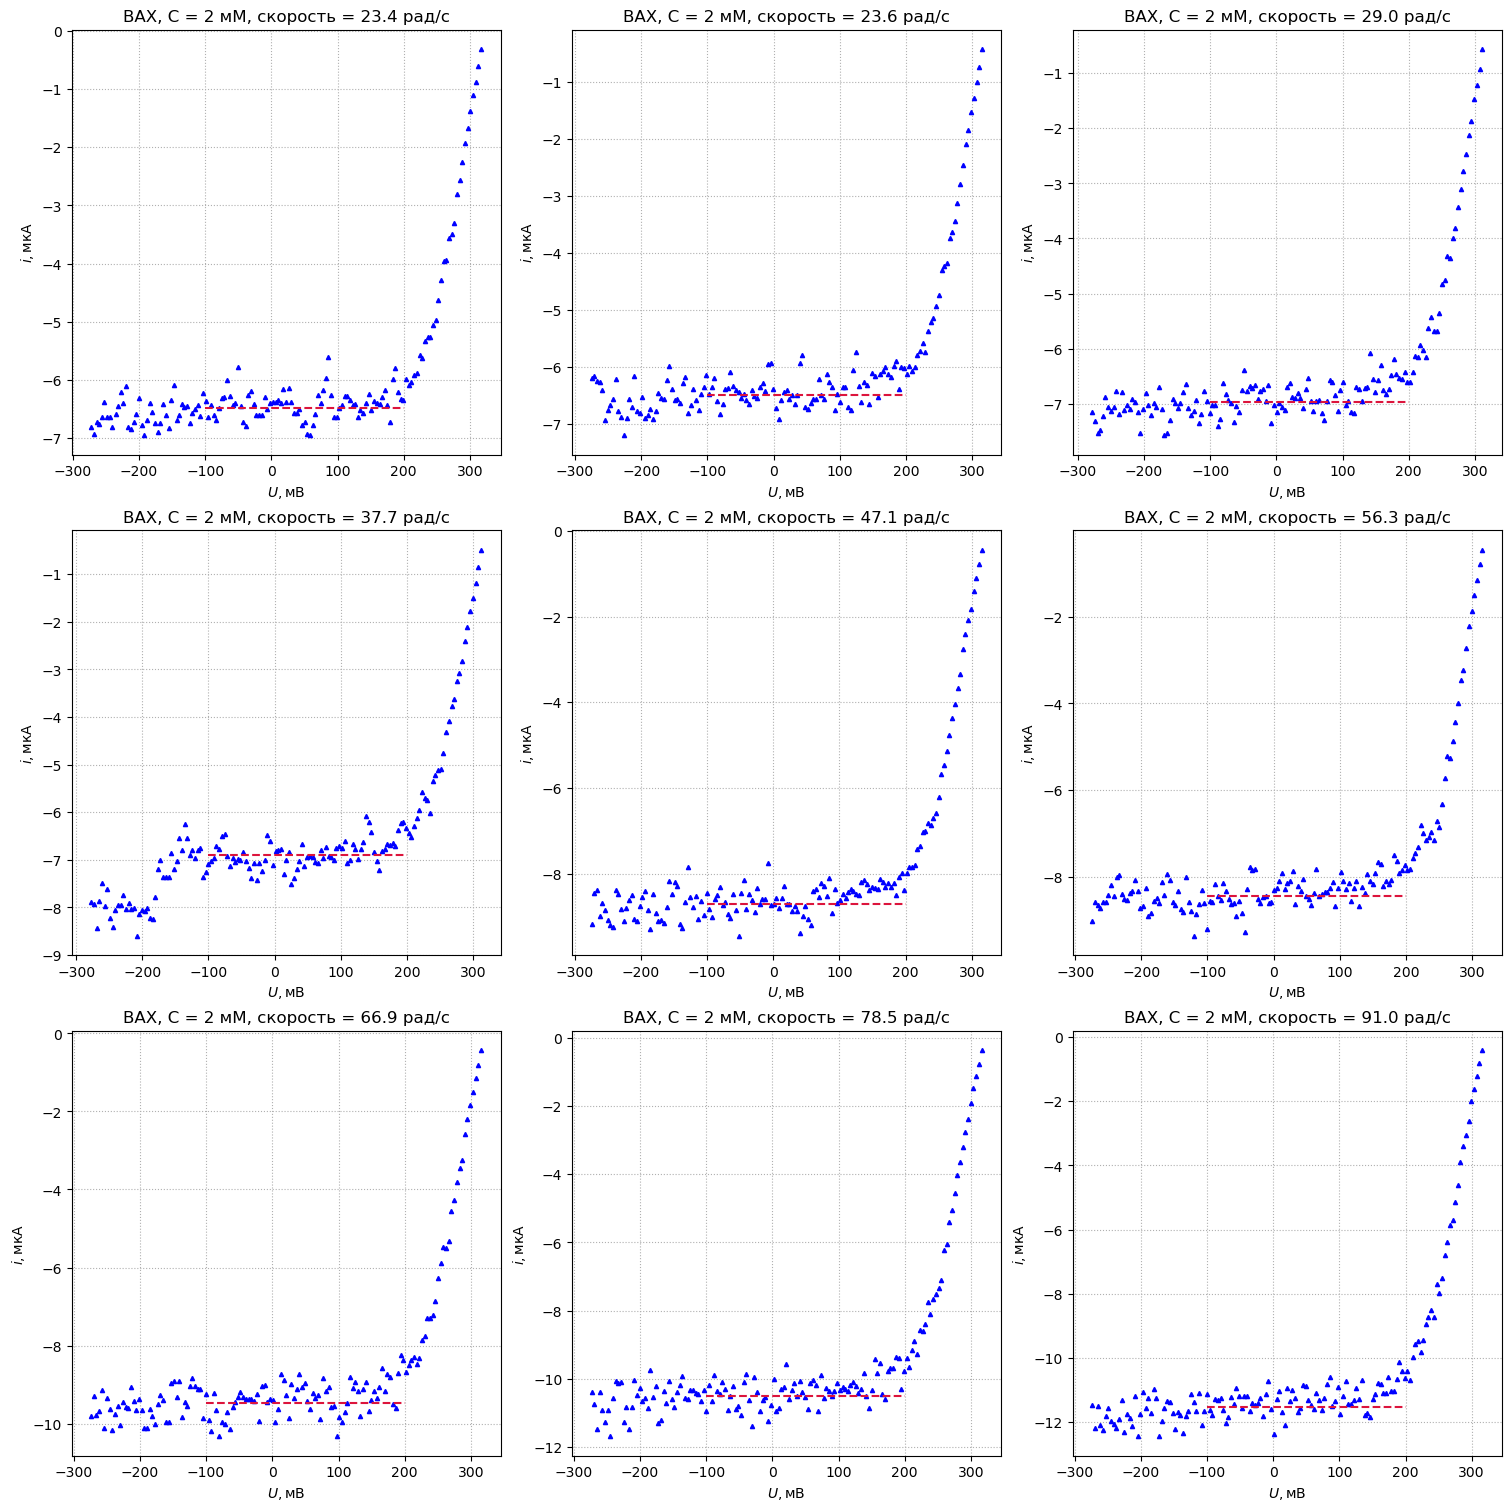

In [951]:
time = []
I = []
U = []
bord = []
for i in range(1, 10):
    path = "electro_2/c5/speed_{}.txt".format(i)
    with open(path, encoding="latin-1") as f:
        lines = f.readlines()[7:]
        i = []
        u = []
        for line in lines:
            mnt = list(map(float, line.strip().split()))
            u.append(mnt[1])
            i.append(mnt[2])
        # i = np.array(i)
        # u = np.array(u)
        I.append(i)
        U.append(u)

i_lim = []
fig, axs = plt.subplots(3, 3, figsize=(15, 15), layout='constrained')
for ax, idx in zip(axs.flat, range(0, 9)):
    mean_cont = []
    for u in U[idx]:
        if u >= x_lims5[idx][0] and u <= x_lims5[idx][1]:
            mean_cont.append(I[idx][U[idx].index(u)])
    mean_i = np.mean(mean_cont)
    i_lim.append(-mean_i)
    ax.set_title(f'ВАХ, C = 2 мМ, скорость = {round(omega[idx], 1)} рад/c')
    ax.plot(U[idx], I[idx], '^', markersize=3, lw=0.01, color="b")
    ax.plot([-100, 200], [mean_i, mean_i], linestyle="--", alpha=1, color="crimson")
    ax.set_xlabel(r'$U, \text{мВ}$', size=10), ax.set_ylabel(r'$i, \text{мкА}$', size=10)
    ax.grid(ls=':')

In [952]:
for i in i_lim:
    print(round(i, 2), end="  ")

6.49  6.49  6.96  6.89  8.69  8.44  9.48  10.52  11.53  

In [953]:
def linear(x, a, b):
    return a*x + b
args, cov = curve_fit(linear, np.sqrt(omega), np.array(i_lim))

In [954]:
args

array([1.03526159, 1.23669283])

In [955]:
np.sqrt(cov)

array([[0.08790276,        nan],
       [       nan, 0.62399596]])

In [956]:
r2 = 1 - cov[0][0] / np.var(np.array(i_lim))**2

In [957]:
r2

0.9991501216604597

In [958]:
k = args[0]
b = args[1]

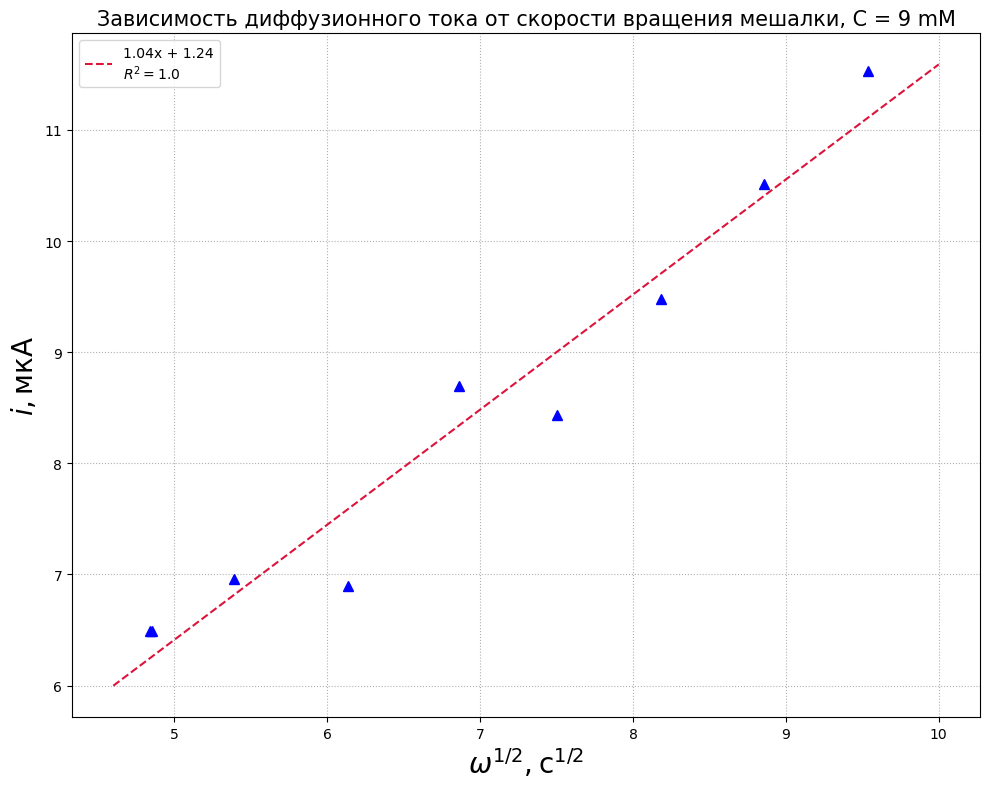

In [961]:
fig, ax = plt.subplots(figsize=(10, 8), layout="tight")
ax.plot(np.sqrt(omega), np.array(i_lim), '^', markersize=7, lw=0.01, color="b")
ax.plot([4.6,10], linear(np.array([4.6, 10]), *args), linestyle="--", alpha=1, color="crimson", label=str(round(k, 2))+ "x + " + str(round(b, 2)) + "\n" + "$R^2 = $" + str(round(r2, 2)))
plt.xlabel(r'$\omega^{1/2}, \text{c}^{1/2}$', size=20), plt.ylabel(r'$i, \text{мкА}$', size=20)
plt.title("Зависимость диффузионного тока от скорости вращения мешалки, С = 9 mM", size=15)
# plt.xlim(0, 0.3)
# plt.ylim(0, 1.4)
ax.grid(ls=':')
plt.legend()

### Исследование зависимости скорости мешалки от номера

In [676]:
omega = np.array([3.753, 4.62, 6, 7.5, 8.968])*6.28

In [677]:
omega

array([23.56884, 29.0136 , 37.68   , 47.1    , 56.31904])

In [751]:
# omega = [12.518546017199842, 14.725133094390014, 
#          20.491541949667916, 26.693171666177104, 30.585233944666832, 
#          38.48051768622663, 44.26913491192255, 57.53781856527062]
omega = np.array([3.753, 4.62, 6, 7.5, 8.968])
N = [i for i in range(1, 6)]

In [752]:
def linear(x, a, b):
    return a*x + b
omega_args, omega_cov = curve_fit(linear, np.array(N), np.sqrt(omega))

In [753]:
omega_args

array([0.27039859, 1.64269406])

In [754]:
omega_cov

array([[ 6.56618409e-05, -1.96985522e-04],
       [-1.96985522e-04,  7.22280239e-04]])

In [755]:
inp = [i for i in range(5, 9)]
omega_new = linear(np.array(inp), *omega_args)**2

In [760]:
omega = [3.731, 3.753, 4.62, 6, 7.5]
for i in omega_new:
    omega.append(i)

In [770]:
omega = np.array(omega)*6.28

In [781]:
for i in omega:
    print(round(i, 1), end=" & ")

23.4 & 23.6 & 29.0 & 37.7 & 47.1 & 56.3 & 66.9 & 78.5 & 91.0 & 

## Определение D

In [995]:
k = np.array([0.25, 0.28, 0.45, 0.75, 1.04])
c = np.array([2, 3, 5, 7, 9]) * 1e-3

In [996]:
def linear(x, a, b):
    return a*x + b
args_d, cov_d = curve_fit(linear, c, k)

In [997]:
args_d

array([ 1.15731708e+02, -4.78048803e-02])

In [998]:
np.sqrt(cov_d)

array([[11.75738811,         nan],
       [        nan,  0.06815229]])

In [999]:
r2 = 0.98

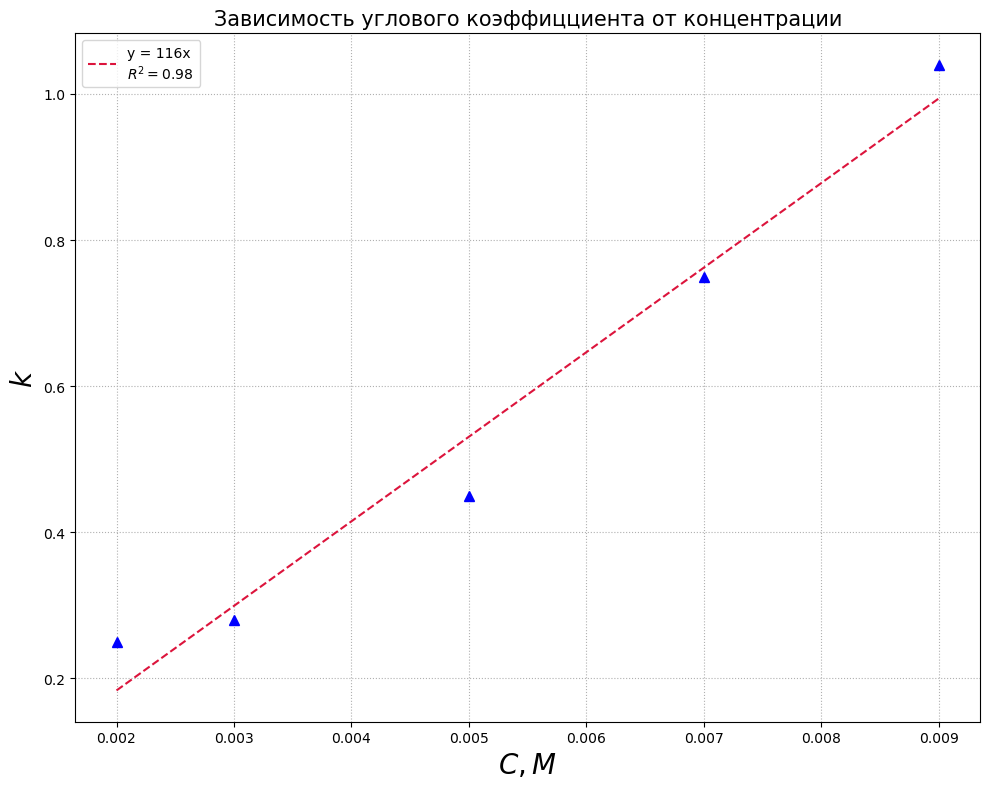

In [1000]:
fig, ax = plt.subplots(figsize=(10, 8), layout="tight")
ax.plot(c, k, '^', markersize=7, lw=0.01, color="b")
ax.plot(c, linear(c, *args_d), linestyle="--", alpha=1, color="crimson", label= "y = " + str(round(args_d[0]))+ "x " + "\n" + "$R^2 = $" + str(round(r2, 2)))
plt.xlabel(r'$C, M$', size=20), plt.ylabel(r'$k$', size=20)
plt.title("Зависимость углового коэффицциента от концентрации", size =15)
# plt.xlim(0, 0.3)
# plt.ylim(0, 1.4)
ax.grid(ls=':')
plt.legend()

In [982]:
np.var(k)

0.090584